# Final Python Notebook 2:Loan Approval Status Classifiers, their performances and Hyperparameters optimisations.

**Author:** K.Bhagya Anuhasini Silva

**Declaration:**

I hereby declare that all the codes included in this notebook were learned and developed during **Seminar Sessions 3 and 4**. The implementation and compilation of these codes are entirely my own work. I also confirm that this work has not been used in any other coursework or submitted for any other academic work previously.

**Code peer Review:**

Reviewer: Thinara Senarathne

Date: 11/03/2026

Test Cases:

*   Use prepared dataset for this notebook










In [ ]:
# Task (4) – Classification Modelling of Loan Approval Status
# Import all Required Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt



In [ ]:
# Load Dataset
df = pd.read_csv("/content/classification_dataset_prepared.csv")

df.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,-1.085843,-1.372135,OWN,-1.174419,EDUCATION,1.039305,-1.214715,-0.427932,N,-0.450108,0
1,-1.085843,-1.340499,OWN,-0.675037,EDUCATION,2.836651,2.006922,0.335502,Y,-0.698298,0
2,-0.754326,-1.435409,RENT,0.074037,MEDICAL,3.735324,0.573985,1.644245,N,-0.698298,0
3,2.063567,3.109818,RENT,-0.425346,EDUCATION,4.633996,-0.882010,0.335502,N,1.287227,0
4,2.063567,0.684242,MORTGAGE,-0.425346,HOMEIMPROVEMENT,4.633996,0.573985,2.516741,N,2.031798,0


In [ ]:
# Define Features and Target
X = df.drop("loan_approval_status", axis=1)
y = df["loan_approval_status"]

print("Feature Names Used:")
print(X.columns)
print("Target variable Used:")
print(y)

print("\nDataset Shape:")
print(X.shape)

Feature Names Used:
Index(['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
       'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length'],
      dtype='object')
Target variable Used:
0        0
1        0
2        0
3        0
4        0
        ..
58640    0
58641    0
58642    0
58643    0
58644    0
Name: loan_approval_status, Length: 58645, dtype: int64

Dataset Shape:
(58645, 10)


In [ ]:
# Drop rows where target is NaN
df = df.dropna(subset=['loan_approval_status'])

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
categorical_vars = ['home_ownership', 'loan_intent', 'payment_default_on_file']
le = LabelEncoder()
for col in categorical_vars:
    df[col] = le.fit_transform(df[col].astype(str))

# Define features and target
X = df.drop('loan_approval_status', axis=1)
y = df['loan_approval_status']

# Confirm no NaN in target
print("NaN in y:", y.isna().sum())
print("Dataset shape after cleaning:", df.shape)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

NaN in y: 0
Dataset shape after cleaning: (58645, 11)
Train shape: (46916, 10)
Test shape: (11729, 10)


In [ ]:
# define numeric data and categorical data
numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include='object').columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns in case train and test have different dummy columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)



In [ ]:
# Feature scalling important for LN and KNN
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# fill missing values while LR cannot train the model with missing values (.fit)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
# print Unique classes in target
print("Unique classes in target:", y.value_counts())

Unique classes in target: loan_approval_status
0    50295
1     8350
Name: count, dtype: int64


In [ ]:
# Logistic regression model
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

In [ ]:
# Naive Bayes model
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:,1]

In [ ]:
# KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:,1]

In [ ]:
# Task (5) – Evaluating your Loan Approval Status Classification Models
# evaluate model using confusion matrix


# evaluate Logistic Regression
print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nLogistic Regression Classification Report")
print(classification_report(y_test, lr_pred))


Logistic Regression Confusion Matrix
[[9806  253]
 [1035  635]]

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.90      0.97      0.94     10059
           1       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



In [ ]:
# evaluate naive bayes
print("Naive Bayes Confusion Matrix")
print(confusion_matrix(y_test, nb_pred))

print("\nNaive Bayes Classification Report")
print(classification_report(y_test, nb_pred))

Naive Bayes Confusion Matrix
[[8957 1102]
 [ 665 1005]]

Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10059
           1       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.70      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729



In [ ]:
# evaluate KNN model
print("KNN Confusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nKNN Classification Report")
print(classification_report(y_test, knn_pred))

KNN Confusion Matrix
[[9812  247]
 [ 759  911]]

KNN Classification Report
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.79      0.55      0.64      1670

    accuracy                           0.91     11729
   macro avg       0.86      0.76      0.80     11729
weighted avg       0.91      0.91      0.91     11729



In [ ]:
# all models were tested on the same test instances (clients) in the dataset
print("Test set shape (same for all models):", X_test.shape)
print("\nLR predictions on X_test:", lr_pred[:5])
print("NB predictions on X_test:", nb_pred[:5])
print("KNN predictions on X_test:", knn_pred[:5])

Test set shape (same for all models): (11729, 10)

LR predictions on X_test: [0 0 0 0 0]
NB predictions on X_test: [0 0 0 0 0]
KNN predictions on X_test: [0 0 0 0 0]


In [ ]:
# the labels ratio of approval Status “Accept” to “Reject” is the same in the training and test subsets
print("Full dataset label ratio:")
print(y.value_counts(normalize=True))

print("\nTraining set label ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest set label ratio:")
print(y_test.value_counts(normalize=True))

Full dataset label ratio:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

Training set label ratio:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

Test set label ratio:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


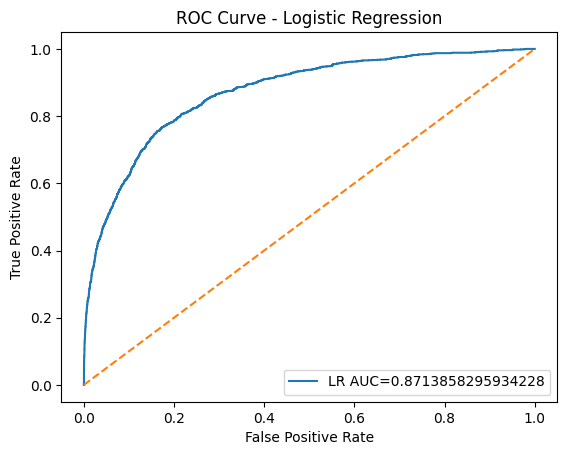

In [ ]:
# AUC-ROC Curve for Logistic Regression and downlaod that graph
fpr, tpr, _ = roc_curve(y_test, lr_prob)
auc_lr = roc_auc_score(y_test, lr_prob)

plt.plot(fpr, tpr, label="LR AUC="+str(auc_lr))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("roc_logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()

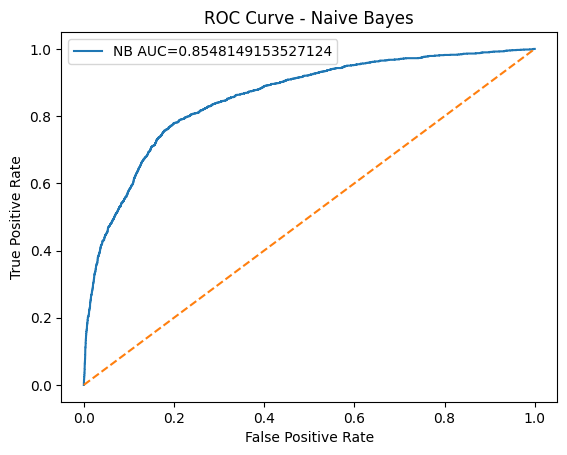

In [ ]:
# AUC-ROC Curve for naive bayes model and downlaod that graph

fpr, tpr, _ = roc_curve(y_test, nb_prob)
auc_nb = roc_auc_score(y_test, nb_prob)

plt.plot(fpr, tpr, label="NB AUC="+str(auc_nb))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.savefig("roc_naive_bayes.png", dpi=300, bbox_inches="tight")
plt.show()


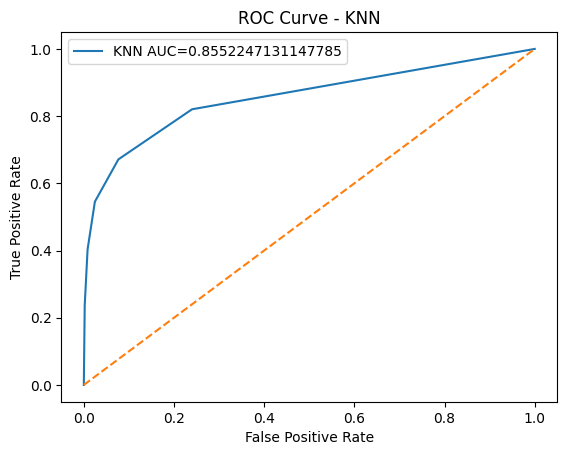

In [ ]:
# AUC-ROC Curve for KNN model and downlaod that graph

fpr, tpr, _ = roc_curve(y_test, knn_prob)
auc_knn = roc_auc_score(y_test, knn_prob)

plt.plot(fpr, tpr, label="KNN AUC="+str(auc_knn))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.savefig("roc_knn.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# tuning hyperparameters to select best model performence
# here we use GridSearchCV for KNN

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors":[3,5,7,9,11],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="recall"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


In [ ]:
# Build Best Tuned Model
best_knn = grid.best_estimator_

best_pred = best_knn.predict(X_test)

print(confusion_matrix(y_test, best_pred))
print(classification_report(y_test, best_pred))

[[9707  352]
 [ 731  939]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10059
           1       0.73      0.56      0.63      1670

    accuracy                           0.91     11729
   macro avg       0.83      0.76      0.79     11729
weighted avg       0.90      0.91      0.90     11729



Voting Ensemble Confusion Matrix
[[9893  166]
 [ 843  827]]

Voting Ensemble Classification Report
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10059
           1       0.83      0.50      0.62      1670

    accuracy                           0.91     11729
   macro avg       0.88      0.74      0.79     11729
weighted avg       0.91      0.91      0.90     11729



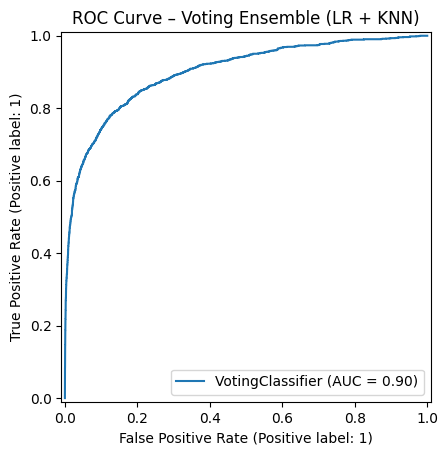

AUC-ROC (Ensemble): 0.9009429991790948


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt



# Drop NaN in target
df = df.dropna(subset=['loan_approval_status'])

# Encode categorical columns
categorical_vars = ['home_ownership', 'loan_intent', 'payment_default_on_file']
le = LabelEncoder()
for col in categorical_vars:
    df[col] = le.fit_transform(df[col].astype(str))

# Define features and target
X = df.drop('loan_approval_status', axis=1)
y = df['loan_approval_status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Declare base learners
lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)

# Declare and fit ensemble
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn)],
    voting='soft'
)
ensemble.fit(X_train, y_train)

# Ensemble predictions
y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("Voting Ensemble Confusion Matrix")
print(confusion_matrix(y_test, y_pred_ens))

# Classification Report
print("\nVoting Ensemble Classification Report")
print(classification_report(y_test, y_pred_ens))

# AUC-ROC Curve
RocCurveDisplay.from_estimator(ensemble, X_test, y_test)
plt.title("ROC Curve – Voting Ensemble (LR + KNN)")
plt.savefig("Voting Ensemble (LR + KNN).png", dpi=300, bbox_inches="tight")
plt.show()

print("AUC-ROC (Ensemble):", roc_auc_score(y_test, y_prob_ens))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

#  BEFORE TUNING (default KNN k=5)
knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train, y_train)
knn_pred_before = knn_default.predict(X_test)
knn_prob_before = knn_default.predict_proba(X_test)[:, 1]

print("- BEFORE TUNING -")
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred_before))
print("\nClassification Report:")
print(classification_report(y_test, knn_pred_before))
print("AUC-ROC:", roc_auc_score(y_test, knn_prob_before))

#  TUNING
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="recall")
grid.fit(X_train, y_train)
print("\nBest Parameters:", grid.best_params_)

# AFTER TUNING
best_knn = grid.best_estimator_
knn_pred_after = best_knn.predict(X_test)
knn_prob_after = best_knn.predict_proba(X_test)[:, 1]

print("\n - AFTER TUNING -")
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred_after))
print("\nClassification Report:")
print(classification_report(y_test, knn_pred_after))
print("AUC-ROC:", roc_auc_score(y_test, knn_prob_after))

- BEFORE TUNING -
Confusion Matrix:
[[9827  232]
 [ 742  928]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.80      0.56      0.66      1670

    accuracy                           0.92     11729
   macro avg       0.86      0.77      0.80     11729
weighted avg       0.91      0.92      0.91     11729

AUC-ROC: 0.8627084929455137

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}

 - AFTER TUNING -
Confusion Matrix:
[[9721  338]
 [ 713  957]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10059
           1       0.74      0.57      0.65      1670

    accuracy                           0.91     11729
   macro avg       0.84      0.77      0.80     11729
weighted avg       0.90      0.91      0.91     11729

AUC-ROC: 0.8411844369715683


In [ ]:
# save evaluate classification model
df.to_csv('/content/Evaluated_classification_dataset_prepared.csv', index=False)